Processing Delta Band...


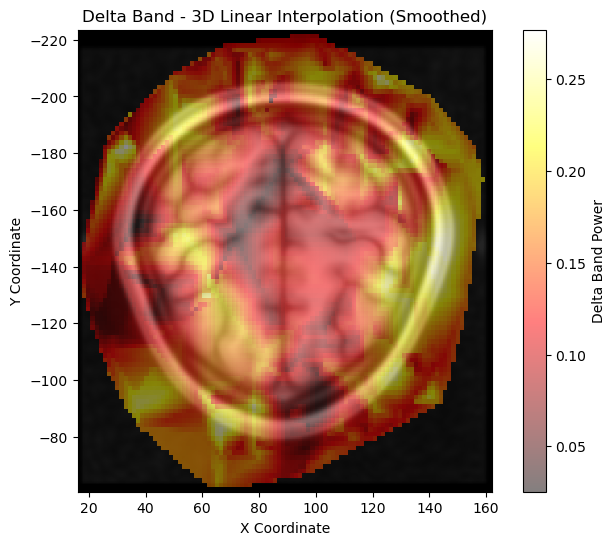

Processing Theta Band...


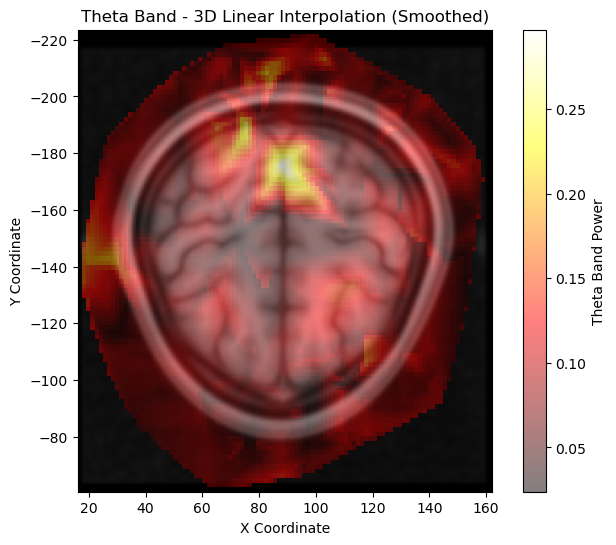

Processing Alpha Band...


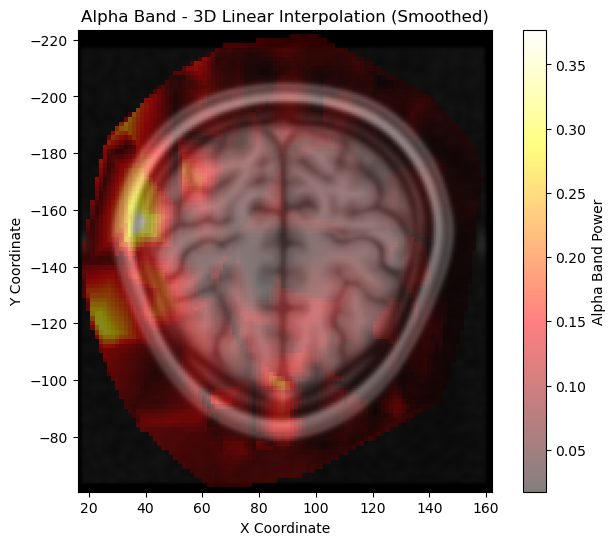

Processing Beta Band...


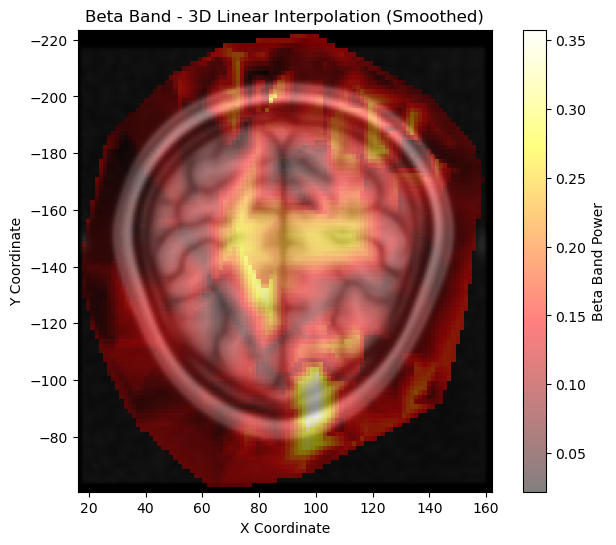

Processing Gamma Band...


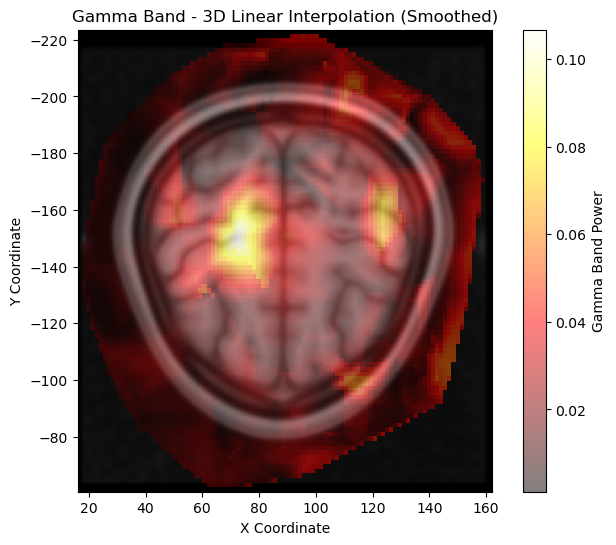


Interpolation Evaluation Metrics:
                MSE       MAE      RMSE        R2
Delta  4.477258e-06  0.000058  0.002116  0.999068
Theta  5.446055e-06  0.000058  0.002334  0.997732
Alpha  4.769933e-07  0.000023  0.000691  0.999799
Beta   2.426604e-06  0.000040  0.001558  0.999527
Gamma  8.684311e-07  0.000025  0.000932  0.997418


In [18]:
import numpy as np
import nibabel as nib
from nilearn import plotting
import matplotlib.pyplot as plt
from scipy.interpolate import griddata
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from math import sqrt
import pandas as pd

# Load coordinates and band power data
coords = np.load('coords.npy')
band_powers = np.load('band_powers.npy', allow_pickle=True).item()

x, y, z = coords[:, 0], coords[:, 1], coords[:, 2]

# Load the MNI file
mni_file_path = '/Users/inayahkhan/Desktop/Group_Diss_Code/MNI152_T1_1mm.nii.gz'
mni_img = nib.load(mni_file_path)
mni_data = mni_img.get_fdata()
mni_affine = mni_img.affine

# Convert coordinates to MNI space using affine
coords_mni = nib.affines.apply_affine(mni_affine, coords)
x_mni, y_mni, z_mni = coords_mni[:, 0], coords_mni[:, 1], coords_mni[:, 2]

# Define a 3D grid for interpolation in MNI space (higher resolution)
resolution = 100  # Increased resolution for finer detail
grid_x, grid_y, grid_z = np.meshgrid(
    np.linspace(x_mni.min(), x_mni.max(), resolution),
    np.linspace(y_mni.min(), y_mni.max(), resolution),
    np.linspace(z_mni.min(), z_mni.max(), resolution)
)

# Prepare a dictionary to store evaluation metrics
evaluation_metrics = {}

# Iterate over each frequency band and perform interpolation
for band, values in band_powers.items():
    print(f'Processing {band} Band...')

    values = np.array(values)

    # Perform 3D linear interpolation
    grid_values = griddata(
        (x_mni, y_mni, z_mni), values, (grid_x, grid_y, grid_z), method='linear'
    )

    # Remove NaNs for evaluation
    interp_values_at_samples = griddata(
        (x_mni, y_mni, z_mni), values, (x_mni, y_mni, z_mni), method='linear'
    )
    valid_mask = ~np.isnan(interp_values_at_samples)
    values_clean = values[valid_mask]
    interp_values_clean = interp_values_at_samples[valid_mask]

    if len(values_clean) > 0:
        mse = mean_squared_error(values_clean, interp_values_clean)
        mae = mean_absolute_error(values_clean, interp_values_clean)
        rmse = sqrt(mse)
        r2 = r2_score(values_clean, interp_values_clean)
    else:
        mse, mae, rmse, r2 = np.nan, np.nan, np.nan, np.nan

    evaluation_metrics[band] = {
        "MSE": mse,
        "MAE": mae,
        "RMSE": rmse,
        "R2": r2
    }

    # Take a 2D slice at the most informative z-coordinate (actually just midpoint)
    slice_idx = resolution // 2
    slice_values = grid_values[:, :, slice_idx]

    # Get the corresponding MNI slice at the same depth
    z_cut = int(np.mean(z_mni))  # Use the mean z-coordinate
    mni_slice = mni_data[:, :, z_cut]

    # Overlay the interpolated data onto the MNI slice
    fig, ax = plt.subplots(figsize=(8, 6))

    # Display the MNI slice directly
    ax.imshow(
        np.rot90(mni_slice),  # Rotate to match orientation
        cmap='gray',
        extent=[x_mni.min(), x_mni.max(), y_mni.min(), y_mni.max()]
    )

    # Overlay the heatmap with increased resolution and smoothing
    sc = ax.imshow(
        np.rot90(slice_values),
        cmap='hot',  # Smoother colormap
        alpha=0.5,
        extent=[x_mni.min(), x_mni.max(), y_mni.min(), y_mni.max()]
    )

    # Fix orientation
    ax.invert_yaxis()

    # Add colorbar
    plt.colorbar(sc, ax=ax, label=f'{band} Band Power')

    # Labeling and title
    ax.set_title(f'{band} Band - 3D Linear Interpolation (Smoothed)')
    ax.set_xlabel('X Coordinate')
    ax.set_ylabel('Y Coordinate')

    plt.show()

# Display evaluation metrics
df_metrics = pd.DataFrame(evaluation_metrics).T
print("\nInterpolation Evaluation Metrics:")
print(df_metrics)


Tried to make it better by adding a gausian filter but i think this may be over smoothing the data? 

Processing Delta Band...


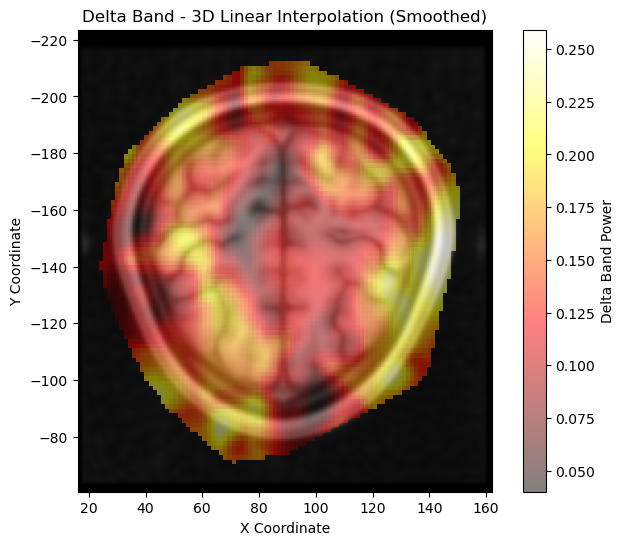

Processing Theta Band...


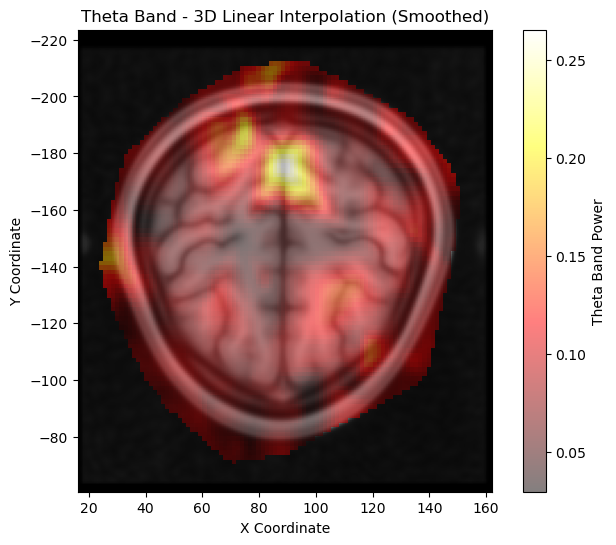

Processing Alpha Band...


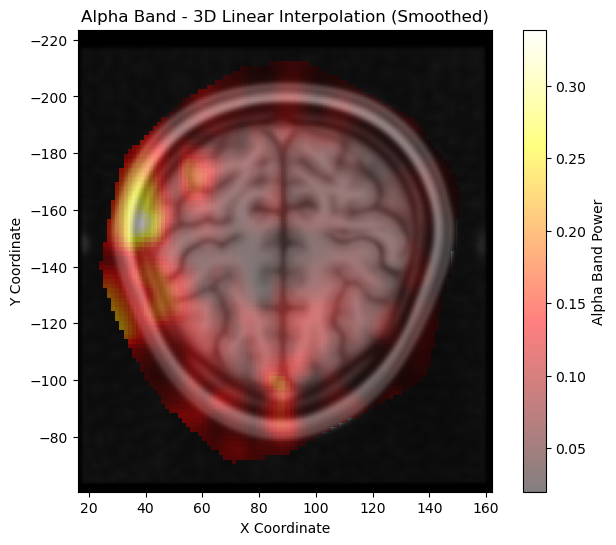

Processing Beta Band...


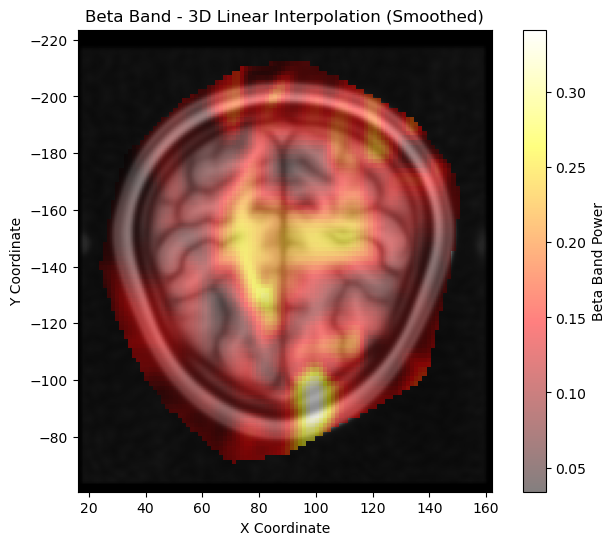

Processing Gamma Band...


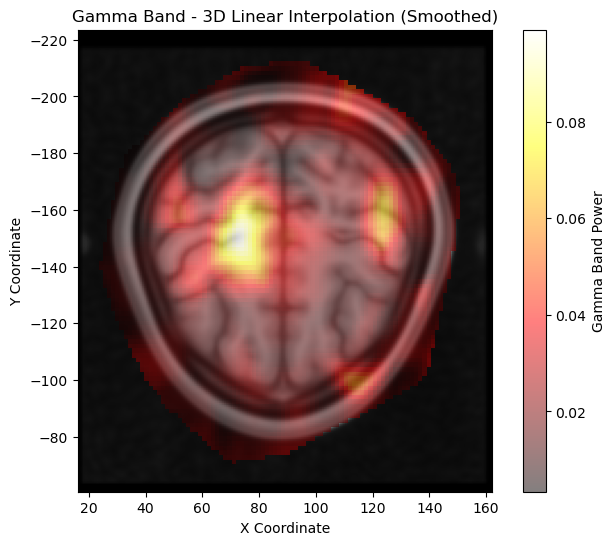


Interpolation Evaluation Metrics:
                MSE       MAE      RMSE        R2
Delta  4.477258e-06  0.000058  0.002116  0.999068
Theta  5.446055e-06  0.000058  0.002334  0.997732
Alpha  4.769933e-07  0.000023  0.000691  0.999799
Beta   2.426604e-06  0.000040  0.001558  0.999527
Gamma  8.684311e-07  0.000025  0.000932  0.997418


In [17]:
from scipy.ndimage import gaussian_filter

# Load coordinates and band power data
coords = np.load('coords.npy')
band_powers = np.load('band_powers.npy', allow_pickle=True).item()

x, y, z = coords[:, 0], coords[:, 1], coords[:, 2]

# Load the MNI file
mni_file_path = '/Users/inayahkhan/Desktop/Group_Diss_Code/MNI152_T1_1mm.nii.gz'
mni_img = nib.load(mni_file_path)
mni_data = mni_img.get_fdata()
mni_affine = mni_img.affine

# Convert coordinates to MNI space using affine
coords_mni = nib.affines.apply_affine(mni_affine, coords)
x_mni, y_mni, z_mni = coords_mni[:, 0], coords_mni[:, 1], coords_mni[:, 2]

# Define a 3D grid for interpolation in MNI space (higher resolution)
resolution = 100  # Increased resolution for finer detail
grid_x, grid_y, grid_z = np.meshgrid(
    np.linspace(x_mni.min(), x_mni.max(), resolution),
    np.linspace(y_mni.min(), y_mni.max(), resolution),
    np.linspace(z_mni.min(), z_mni.max(), resolution)
)

# Prepare a dictionary to store evaluation metrics
evaluation_metrics = {}

# Iterate over each frequency band and perform interpolation
for band, values in band_powers.items():
    print(f'Processing {band} Band...')

    values = np.array(values)

    # Perform 3D linear interpolation
    grid_values = griddata(
        (x_mni, y_mni, z_mni), values, (grid_x, grid_y, grid_z), method='linear'
    )

    # Apply Gaussian smoothing to reduce noise
    grid_values = gaussian_filter(grid_values, sigma=1)

    # Remove NaNs for evaluation
    interp_values_at_samples = griddata(
        (x_mni, y_mni, z_mni), values, (x_mni, y_mni, z_mni), method='linear'
    )
    valid_mask = ~np.isnan(interp_values_at_samples)
    values_clean = values[valid_mask]
    interp_values_clean = interp_values_at_samples[valid_mask]

    if len(values_clean) > 0:
        mse = mean_squared_error(values_clean, interp_values_clean)
        mae = mean_absolute_error(values_clean, interp_values_clean)
        rmse = sqrt(mse)
        r2 = r2_score(values_clean, interp_values_clean)
    else:
        mse, mae, rmse, r2 = np.nan, np.nan, np.nan, np.nan

    evaluation_metrics[band] = {
        "MSE": mse,
        "MAE": mae,
        "RMSE": rmse,
        "R2": r2
    }

    # Take a 2D slice at the most informative z-coordinate (actually just midpoint)
    slice_idx = resolution // 2
    slice_values = grid_values[:, :, slice_idx]

    # Get the corresponding MNI slice at the same depth
    z_cut = int(np.mean(z_mni))  # Use the mean z-coordinate
    mni_slice = mni_data[:, :, z_cut]

    # Overlay the interpolated data onto the MNI slice
    fig, ax = plt.subplots(figsize=(8, 6))

    # Display the MNI slice directly
    ax.imshow(
        np.rot90(mni_slice),  # Rotate to match orientation
        cmap='gray',
        extent=[x_mni.min(), x_mni.max(), y_mni.min(), y_mni.max()]
    )

    # Overlay the heatmap with increased resolution and smoothing
    sc = ax.imshow(
        np.rot90(slice_values),
        cmap='hot',  # Smoother colormap
        alpha=0.5,
        extent=[x_mni.min(), x_mni.max(), y_mni.min(), y_mni.max()]
    )

    # Fix orientation
    ax.invert_yaxis()

    # Add colorbar
    plt.colorbar(sc, ax=ax, label=f'{band} Band Power')

    # Labeling and title
    ax.set_title(f'{band} Band - 3D Linear Interpolation (Smoothed)')
    ax.set_xlabel('X Coordinate')
    ax.set_ylabel('Y Coordinate')

    plt.show()

# Display evaluation metrics
df_metrics = pd.DataFrame(evaluation_metrics).T
print("\nInterpolation Evaluation Metrics:")
print(df_metrics)
